In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv("Video_Games.csv")
print("Shape:", df.shape)
df.head()

Shape: (16928, 17)


,index,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16928 entries, 0 to 16927
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            16928 non-null  int64  
 1   Name             16926 non-null  object 
 2   Platform         16928 non-null  object 
 3   Year_of_Release  16655 non-null  float64
 4   Genre            16926 non-null  object 
 5   Publisher        16873 non-null  object 
 6   NA_Sales         16928 non-null  float64
 7   EU_Sales         16928 non-null  float64
 8   JP_Sales         16928 non-null  float64
 9   Other_Sales      16928 non-null  float64
 10  Global_Sales     16928 non-null  float64
 11  Critic_Score     8260 non-null   float64
 12  Critic_Count     8260 non-null   float64
 13  User_Score       10159 non-null  object 
 14  User_Count       7718 non-null   float64
 15  Developer        10240 non-null  object 
 16  Rating           10092 non-null  object 
dtypes: float64(9

In [4]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing

User_Count         54.406900
Critic_Score       51.205104
Critic_Count       51.205104
Rating             40.382798
User_Score         39.987004
Developer          39.508507
Year_of_Release     1.612713
Publisher           0.324905
Genre               0.011815
Name                0.011815
index               0.000000
Global_Sales        0.000000
Other_Sales         0.000000
EU_Sales            0.000000
NA_Sales            0.000000
Platform            0.000000
JP_Sales            0.000000
dtype: float64

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
display(df.dtypes)

nunique = df.nunique(dropna=True).sort_values(ascending=False)
display(nunique.to_frame("n_unique"))

Duplicate rows: 0


index                int64
Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score          object
User_Count         float64
Developer           object
Rating              object
dtype: object

,n_unique
index,16928
Name,11562
Developer,1696
User_Count,888
Global_Sales,629
Publisher,581
NA_Sales,402
EU_Sales,307
JP_Sales,244
Other_Sales,155


In [ ]:
df["Hit"] = (df["Global_Sales"] > 1.0).astype(int)
df["Hit"].value_counts(), (df["Hit"].value_counts(normalize=True) * 100)

(Hit
 0    14856
 1     2072
 Name: count, dtype: int64,
 Hit
 0    87.759924
 1    12.240076
 Name: proportion, dtype: float64)

In [16]:
df["User_Score"] = df["User_Score"].replace("tbd", np.nan)
df["User_Score"] = pd.to_numeric(df["User_Score"], errors="coerce")

In [17]:
miss_by_class = df.groupby("Hit").apply(lambda g: g.isnull().mean()*100)
display(miss_by_class.T.sort_values(by=0, ascending=False).head(15))

Hit,0,1
User_Count,57.397684,32.963320
User_Score,57.397684,32.963320
Critic_Score,53.574313,34.218147
Critic_Count,53.574313,34.218147
Rating,41.733980,30.694981
Developer,40.764674,30.501931
Year_of_Release,1.689553,1.061776
Publisher,0.350027,0.144788
Genre,0.006731,0.048263
Name,0.006731,0.048263


,count,mean,std,min,25%,50%,75%,max
index,16928.0,8463.500000,4886.837014,0.00,4231.75,8463.50,12695.25,16927.00
Year_of_Release,16655.0,2006.485320,5.882890,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16928.0,0.266390,0.814326,0.00,0.00,0.08,0.24,41.36
EU_Sales,16928.0,0.146850,0.504585,0.00,0.00,0.02,0.11,28.96
JP_Sales,16928.0,0.078170,0.308756,0.00,0.00,0.00,0.04,10.22
Other_Sales,16928.0,0.047861,0.186675,0.00,0.00,0.01,0.04,10.57
Global_Sales,16928.0,0.539520,1.550545,0.01,0.06,0.17,0.49,82.53
Critic_Score,8260.0,69.037893,13.943198,13.00,60.00,71.00,79.00,98.00
Critic_Count,8260.0,26.428692,18.989929,3.00,12.00,22.00,36.00,113.00
User_Score,7718.0,7.125926,1.498886,0.00,6.40,7.50,8.20,9.70


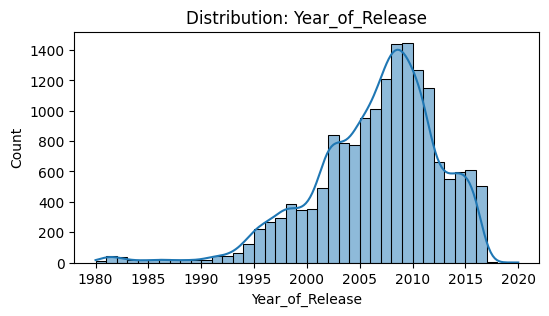

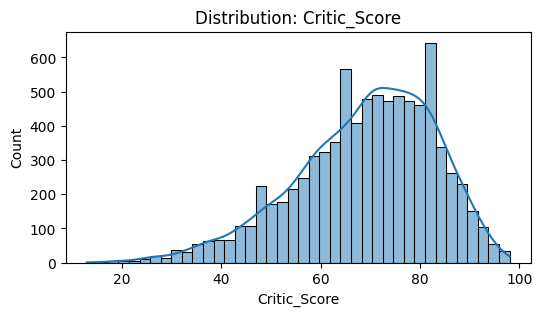

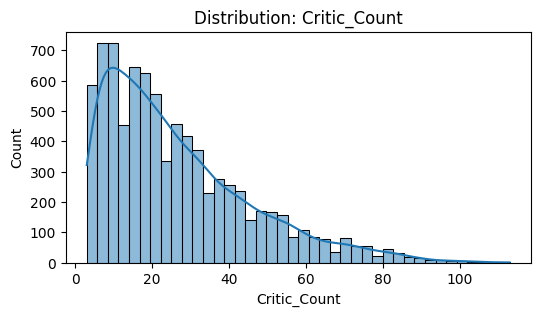

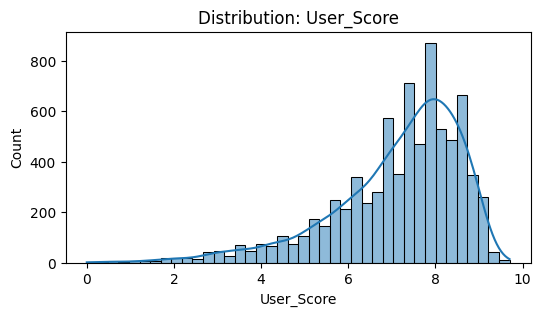

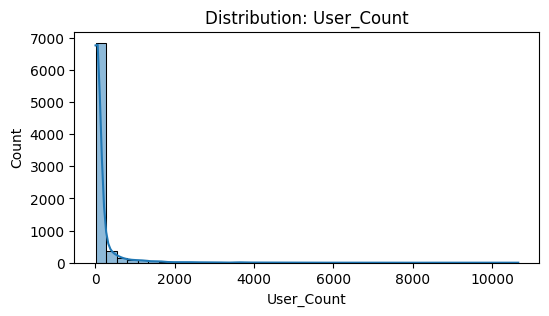

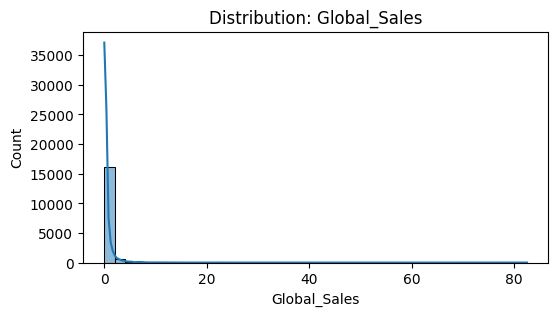

,IQR_outlier_%
User_Count,14.135786
Global_Sales,10.733696
User_Score,4.003628
Critic_Count,3.111380
Year_of_Release,1.855299
Critic_Score,1.004843


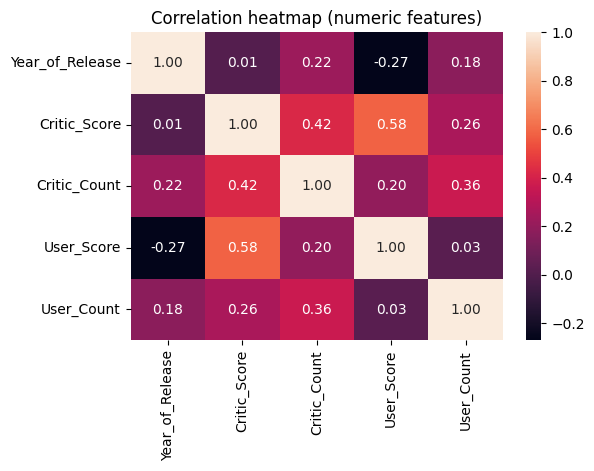

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
display(df[num_cols].describe().T)

key_num = ["Year_of_Release", "Critic_Score", "Critic_Count", "User_Score", "User_Count", "Global_Sales"]
key_num = [c for c in key_num if c in df.columns]

for c in key_num:
    plt.figure(figsize=(6,3))
    sns.histplot(df[c], bins=40, kde=True)
    plt.title(f"Distribution: {c}")
    plt.show()

def iqr_outlier_rate(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) < 10:
        return np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < lo) | (s > hi)).mean() * 100

outlier_rates = {c: iqr_outlier_rate(df[c]) for c in key_num}
display(pd.Series(outlier_rates).sort_values(ascending=False).to_frame("IQR_outlier_%"))

corr_cols = [c for c in ["Year_of_Release","Critic_Score","Critic_Count","User_Score","User_Count"] if c in df.columns]
plt.figure(figsize=(6,4))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation heatmap (numeric features)")
plt.show()

In [ ]:
leakage_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]
df = df.drop(columns=leakage_cols)

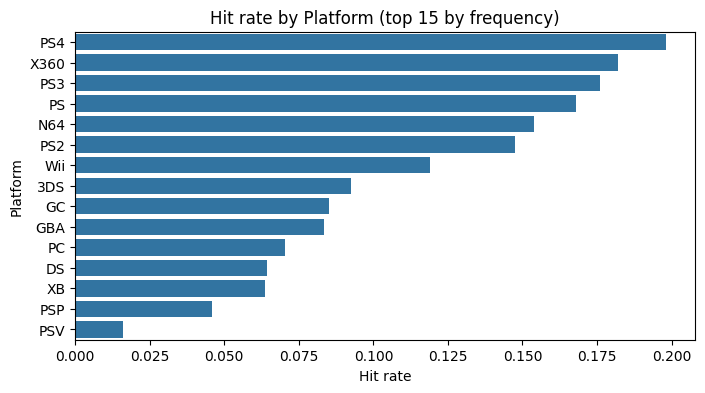

,Platform,hit_rate,n
0,PS4,0.197995,399
1,X360,0.182031,1280
2,PS3,0.175865,1359
3,PS,0.168040,1214
4,N64,0.153846,325
5,PS2,0.147623,2188
6,Wii,0.118923,1337
7,3DS,0.092453,530
8,GC,0.085106,564
9,GBA,0.083433,839


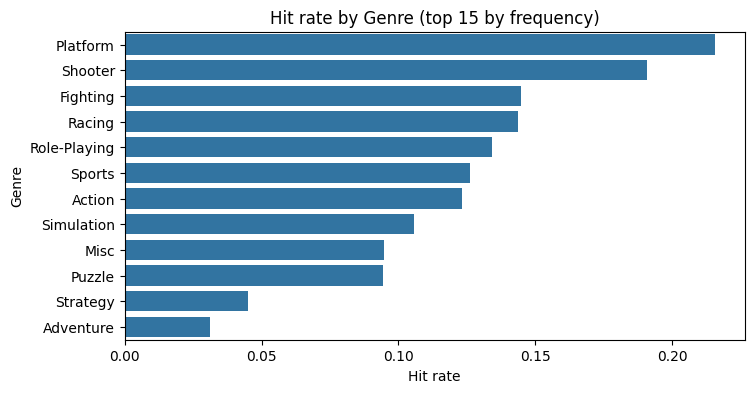

,Genre,hit_rate,n
0,Platform,0.215708,904
1,Shooter,0.190794,1347
2,Fighting,0.144844,863
3,Racing,0.143760,1266
4,Role-Playing,0.134299,1519
5,Sports,0.126050,2380
6,Action,0.123167,3410
7,Simulation,0.105682,880
8,Misc,0.094755,1773
9,Puzzle,0.094502,582


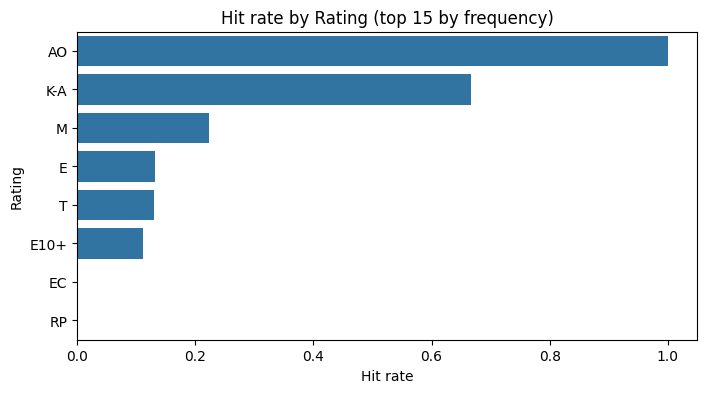

,Rating,hit_rate,n
0,AO,1.000000,1
1,K-A,0.666667,3
2,M,0.223270,1590
3,E,0.130843,4043
4,T,0.129204,3003
5,E10+,0.111728,1441
6,EC,0.000000,8
7,RP,0.000000,3


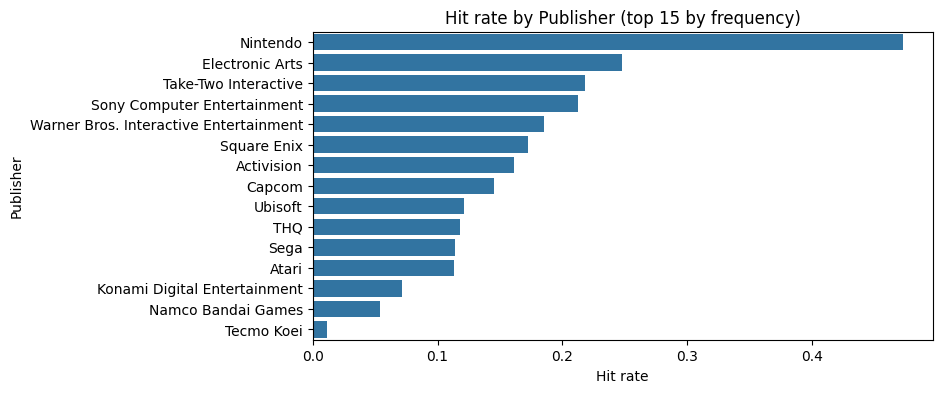

,Publisher,hit_rate,n
0,Nintendo,0.472954,721
1,Electronic Arts,0.247660,1389
2,Take-Two Interactive,0.217799,427
3,Sony Computer Entertainment,0.212553,701
4,Warner Bros. Interactive Entertainment,0.185654,237
5,Square Enix,0.172269,238
6,Activision,0.161515,1003
7,Capcom,0.145408,392
8,Ubisoft,0.121308,948
9,THQ,0.117729,722


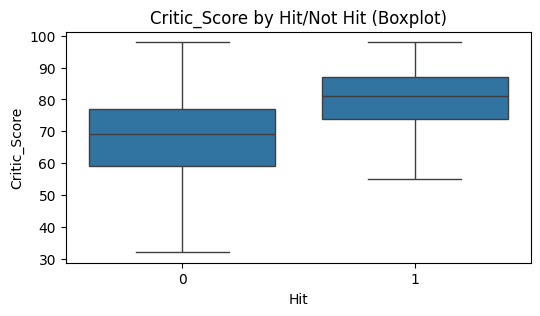

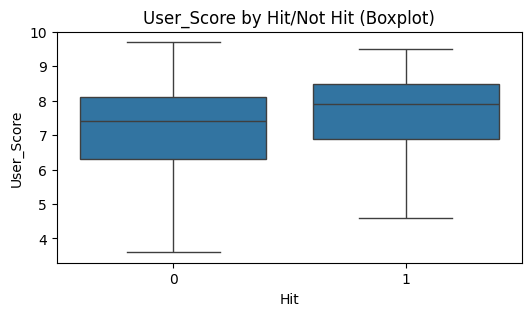

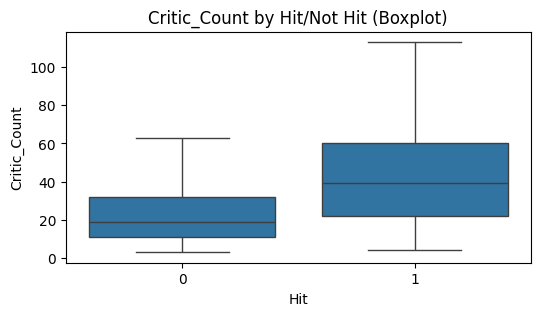

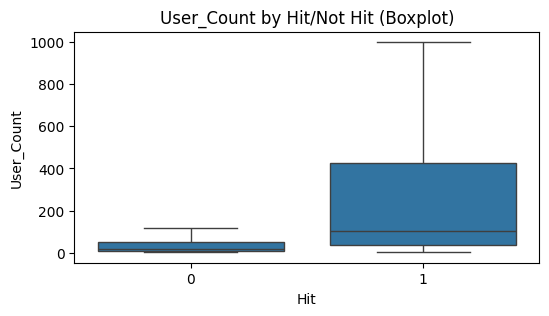

In [ ]:
def plot_hit_rate_cat(col, top_n=15):
    tmp = df[[col,"Hit"]].dropna()
    top = tmp[col].value_counts().head(top_n).index
    stats = (tmp[tmp[col].isin(top)]
             .groupby(col)["Hit"].agg(hit_rate="mean", n="size")
             .sort_values("hit_rate", ascending=False)
             .reset_index())
    plt.figure(figsize=(8,4))
    sns.barplot(data=stats, x="hit_rate", y=col)
    plt.title(f"Hit rate by {col} (top {top_n} by frequency)")
    plt.xlabel("Hit rate"); plt.show()
    display(stats)

for col in ["Platform","Genre","Rating","Publisher"]:
    if col in df.columns:
        plot_hit_rate_cat(col)

for c in ["Critic_Score","User_Score","Critic_Count","User_Count"]:
    if c in df.columns:
        plt.figure(figsize=(6,3))
        sns.boxplot(data=df, x="Hit", y=c, showfliers=False) 
        plt.title(f"{c} by Hit/Not Hit")
        plt.show()

In [24]:
features = [
    "Platform",
    "Year_of_Release",
    "Genre",
    "Publisher",
    "Critic_Score",
    "Critic_Count",
    "User_Score",
    "User_Count",
    "Rating"
]

X = df[features]
y = df["Hit"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (13542, 9) Test: (3386, 9)


In [26]:
numeric_features = ["Year_of_Release", "Critic_Score", "Critic_Count", "User_Score", "User_Count"]
categorical_features = ["Platform", "Genre", "Publisher", "Rating"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [27]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.796219728292971
Precision: 0.34934497816593885
Recall   : 0.7729468599033816
F1-score : 0.48120300751879697

Classification report:

              precision    recall  f1-score   support

           0       0.96      0.80      0.87      2972
           1       0.35      0.77      0.48       414

    accuracy                           0.80      3386
   macro avg       0.66      0.79      0.68      3386
weighted avg       0.89      0.80      0.83      3386



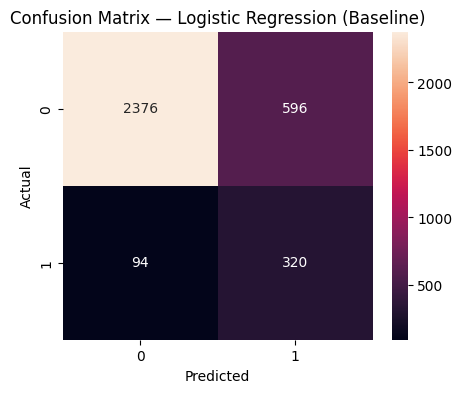

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression (Baseline)")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=None
    ))
])

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print("Decision Tree Results")
print("Accuracy :", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall   :", recall_score(y_test, tree_pred))
print("F1-score :", f1_score(y_test, tree_pred))
print("\nClassification report:\n")
print(classification_report(y_test, tree_pred))

Decision Tree Results
Accuracy : 0.8789131718842291
Precision: 0.5044052863436124
Recall   : 0.5531400966183575
F1-score : 0.5276497695852534

Classification report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2972
           1       0.50      0.55      0.53       414

    accuracy                           0.88      3386
   macro avg       0.72      0.74      0.73      3386
weighted avg       0.88      0.88      0.88      3386



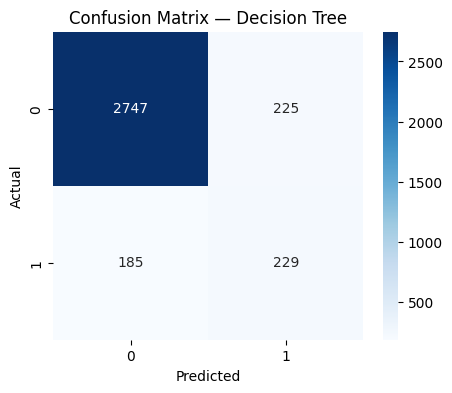

In [ ]:
cm_tree = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Decision Tree")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1-score :", f1_score(y_test, rf_pred))

print("\nClassification report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Results
Accuracy : 0.9054932073242764
Precision: 0.6753731343283582
Recall   : 0.43719806763285024
F1-score : 0.530791788856305

Classification report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2972
           1       0.68      0.44      0.53       414

    accuracy                           0.91      3386
   macro avg       0.80      0.70      0.74      3386
weighted avg       0.89      0.91      0.90      3386



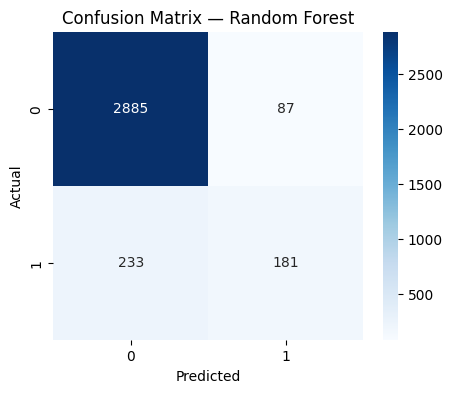

In [ ]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.show()

In [ ]:
from sklearn.svm import LinearSVC

svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=20000
    ))
])

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print("Linear SVM Results")
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1-score :", f1_score(y_test, svm_pred))

print("\nClassification report:\n")
print(classification_report(y_test, svm_pred))

Linear SVM Results
Accuracy : 0.7861783815711755
Precision: 0.33718487394957986
Recall   : 0.7753623188405797
F1-score : 0.4699853587115666

Classification report:

              precision    recall  f1-score   support

           0       0.96      0.79      0.87      2972
           1       0.34      0.78      0.47       414

    accuracy                           0.79      3386
   macro avg       0.65      0.78      0.67      3386
weighted avg       0.89      0.79      0.82      3386



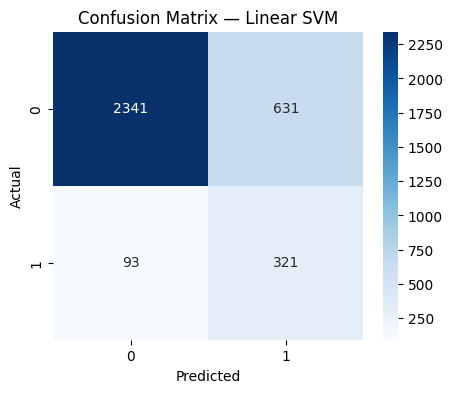

In [35]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Linear SVM")
plt.show()


In [36]:
from sklearn.metrics import precision_recall_curve

rf_probs = rf_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, rf_probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])
print("Precision at best:", precision[best_idx])
print("Recall at best:", recall[best_idx])

Best threshold: 0.31333333333333335
Best F1: 0.6148409888995992
Precision at best: 0.6
Recall at best: 0.6304347826086957


Random Forest (Threshold Tuned) Results
Accuracy : 0.903425871234495
Precision: 0.6
Recall   : 0.6304347826086957
F1-score : 0.6148409893992933

Classification report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94      2972
           1       0.60      0.63      0.61       414

    accuracy                           0.90      3386
   macro avg       0.77      0.79      0.78      3386
weighted avg       0.91      0.90      0.90      3386



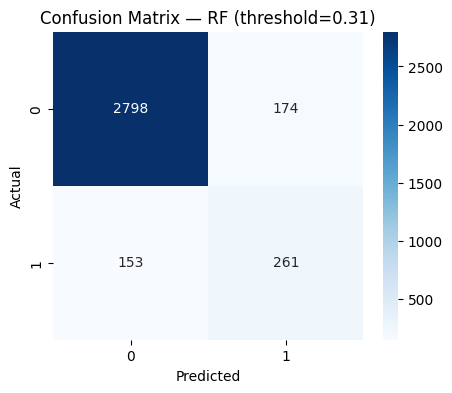

In [37]:
rf_pred_thr = (rf_probs >= best_threshold).astype(int)

print("Random Forest (Threshold Tuned) Results")
print("Accuracy :", accuracy_score(y_test, rf_pred_thr))
print("Precision:", precision_score(y_test, rf_pred_thr))
print("Recall   :", recall_score(y_test, rf_pred_thr))
print("F1-score :", f1_score(y_test, rf_pred_thr))
print("\nClassification report:\n")
print(classification_report(y_test, rf_pred_thr))

cm_thr = confusion_matrix(y_test, rf_pred_thr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_thr, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — RF (threshold={best_threshold:.2f})")
plt.show()

In [ ]:
import mlflow
import mlflow.sklearn
from pathlib import Path

mlflow.set_experiment("VideoGameHitPrediction")

def log_run(model_name, model_obj, y_true, y_pred, params=None, artifact_path="artifacts"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    with mlflow.start_run(run_name=model_name):
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1", f1)

        if params:
            mlflow.log_params(params)

        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix — {model_name}")
        
        Path(artifact_path).mkdir(exist_ok=True)
        cm_path = f"{artifact_path}/{model_name}_cm.png"
        plt.savefig(cm_path, bbox_inches="tight")
        plt.close()

        mlflow.log_artifact(cm_path)
      
        mlflow.sklearn.log_model(model_obj, "model")

    print(f"Logged to MLflow: {model_name} | F1={f1:.3f}")

Traceback (most recent call last):
  File "c:\Users\mvasi\AppData\Local\Programs\Python\Python310\lib\site-packages\mlflow\store\tracking\file_store.py", line 378, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\mvasi\AppData\Local\Programs\Python\Python310\lib\site-packages\mlflow\store\tracking\file_store.py", line 476, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\mvasi\AppData\Local\Programs\Python\Python310\lib\site-packages\mlflow\store\tracking\file_store.py", line 1646, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\mvasi\AppData\Local\Programs\Python\Python310\lib\site-packages\mlflow\store\tracking\file_store.py", line 1639, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\mvasi\AppData\Local\Programs\Python\Python310\lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r

In [39]:
log_run(
    model_name="RandomForest_TunedThreshold",
    model_obj=rf_model,
    y_true=y_test,
    y_pred=rf_pred_thr,
    params={
        "n_estimators": 300,
        "class_weight": "balanced",
        "threshold": float(best_threshold)
    }
)


2025/12/15 16:37:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged to MLflow: RandomForest_TunedThreshold | F1=0.615


In [40]:
log_run(
    model_name="LogisticRegression_Baseline",
    model_obj=model,
    y_true=y_test,
    y_pred=y_pred,
    params={
        "model": "LogisticRegression",
        "class_weight": "balanced"
    }
)

2025/12/15 16:37:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged to MLflow: LogisticRegression_Baseline | F1=0.481


In [41]:
log_run(
    model_name="DecisionTree",
    model_obj=tree_model,
    y_true=y_test,
    y_pred=tree_pred,
    params={
        "model": "DecisionTree",
        "class_weight": "balanced"
    }
)

2025/12/15 16:38:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged to MLflow: DecisionTree | F1=0.528


In [42]:
log_run(
    model_name="RandomForest_DefaultThreshold",
    model_obj=rf_model,
    y_true=y_test,
    y_pred=rf_pred,
    params={
        "model": "RandomForest",
        "n_estimators": 300,
        "class_weight": "balanced",
        "threshold": 0.5
    }
)

2025/12/15 16:38:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged to MLflow: RandomForest_DefaultThreshold | F1=0.531


In [43]:
log_run(
    model_name="LinearSVM",
    model_obj=svm_model,
    y_true=y_test,
    y_pred=svm_pred,
    params={
        "model": "LinearSVM",
        "class_weight": "balanced"
    }
)

2025/12/15 16:38:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged to MLflow: LinearSVM | F1=0.470
